In [2]:
import numpy as np
import pandas as pd

In [10]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
df = pd.read_csv(url, header=None)
df.columns = ['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

In [ ]:
df.head()


,Pregnancies,Glucose,BP,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
uf =df[['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age',]]

# Removing Outcome id 
which will not in use 

In [16]:
uf.sample( 10)

,Pregnancies,Glucose,BP,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
33,6,92,92,0,0,19.9,0.188,28
135,2,125,60,20,140,33.8,0.088,31
264,4,123,62,0,0,32.0,0.226,35
762,9,89,62,0,0,22.5,0.142,33
391,5,166,76,0,0,45.7,0.340,27
323,13,152,90,33,29,26.8,0.731,43
514,3,99,54,19,86,25.6,0.154,24
651,1,117,60,23,106,33.8,0.466,27
86,13,106,72,54,0,36.6,0.178,45
549,4,189,110,31,0,28.5,0.680,37


# Note that no missing  value are present here that why     


 * No need og drop value -- > dropna(0)


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

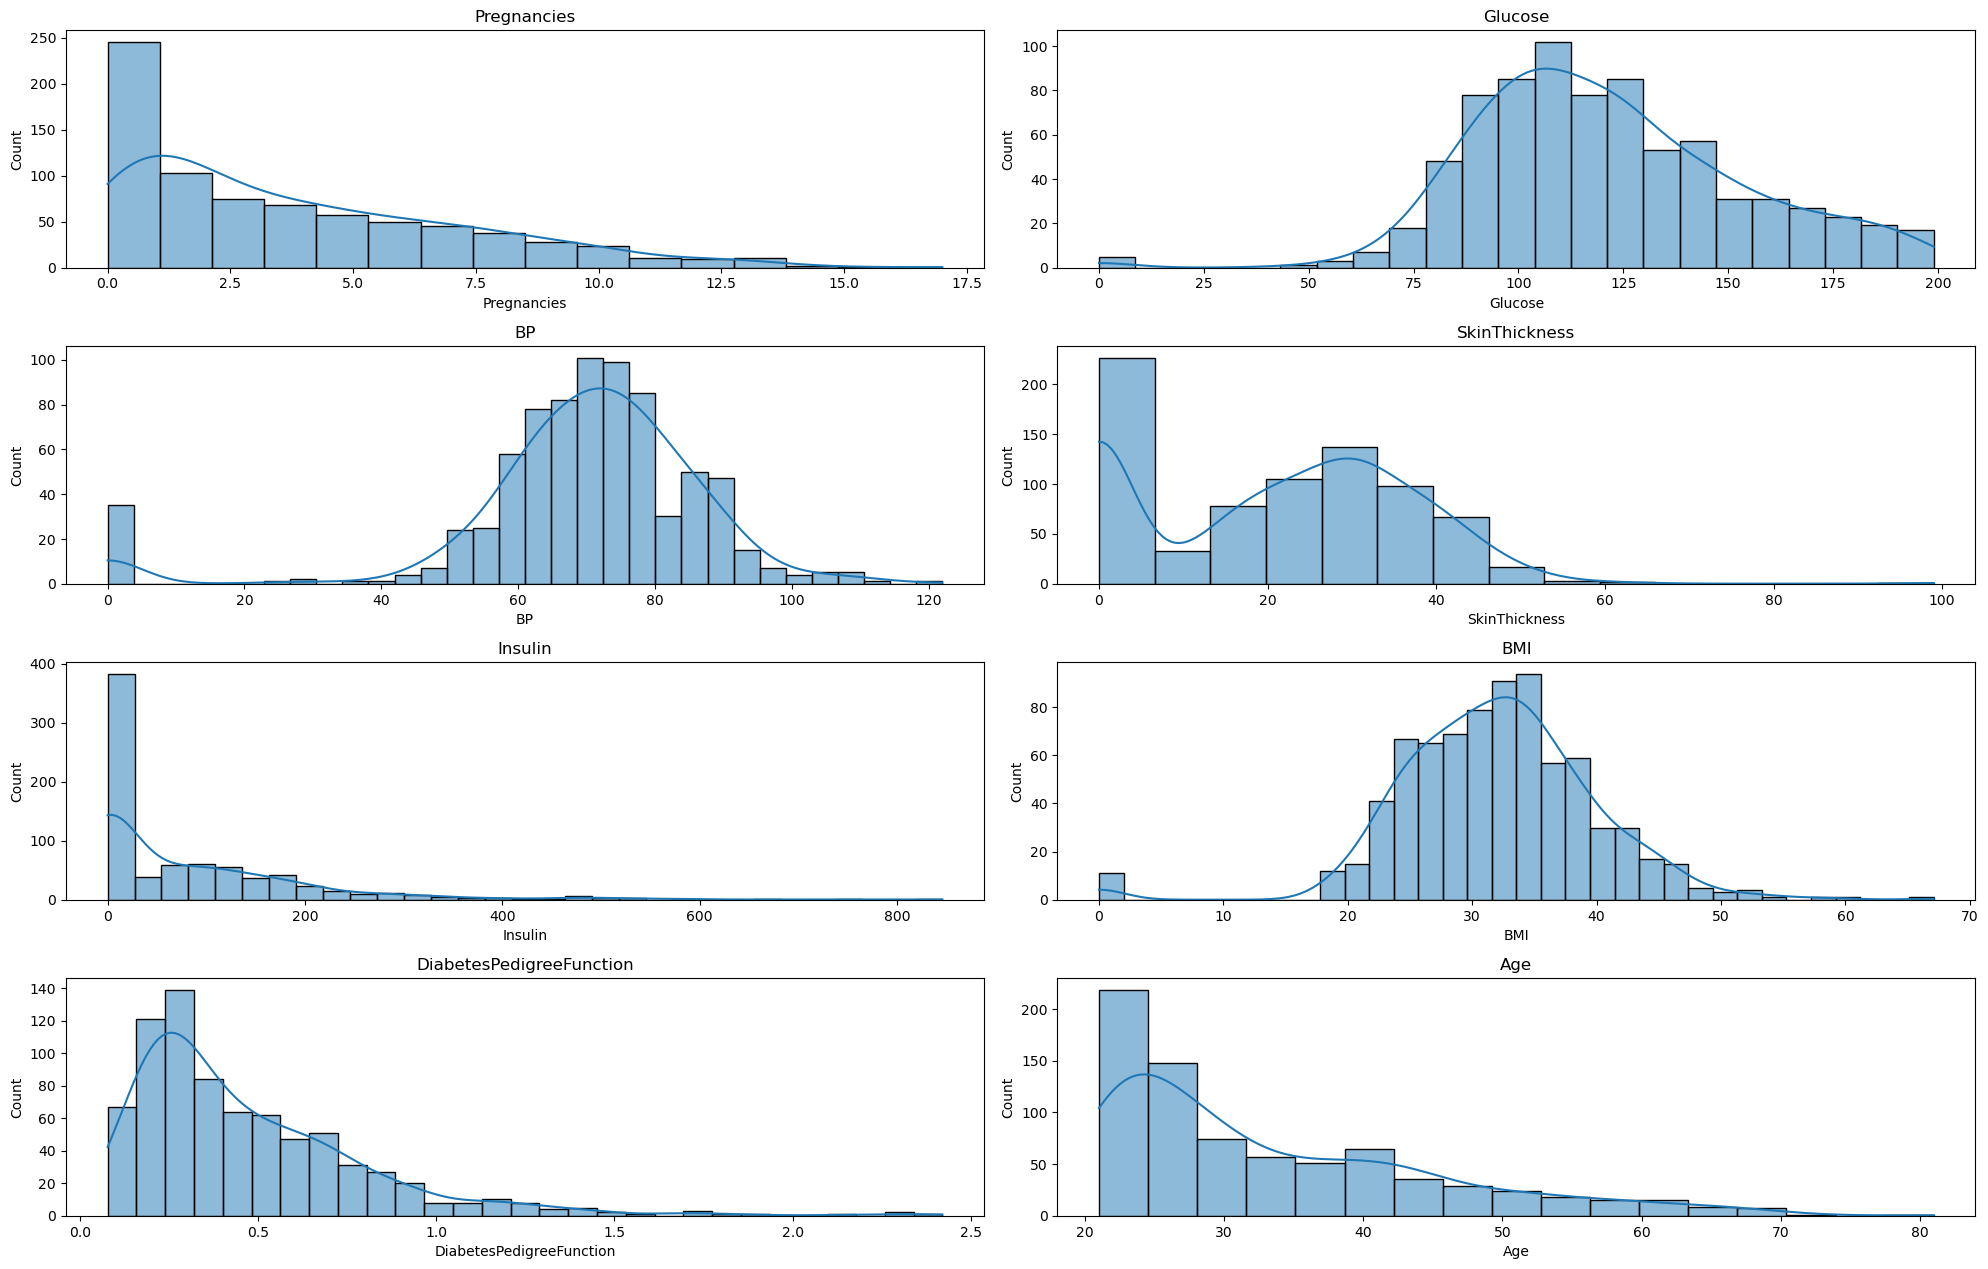

In [28]:
col = ['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age',]


plt.figure(figsize=(20,25))
for i, col in enumerate( col , 1 ): # why 1 here ? need to ask deep seek 
    plt.subplot(8, 2, i)
    sns.histplot(uf[col], kde=True)
    plt.title(col) 
plt.tight_layout()
plt.show()


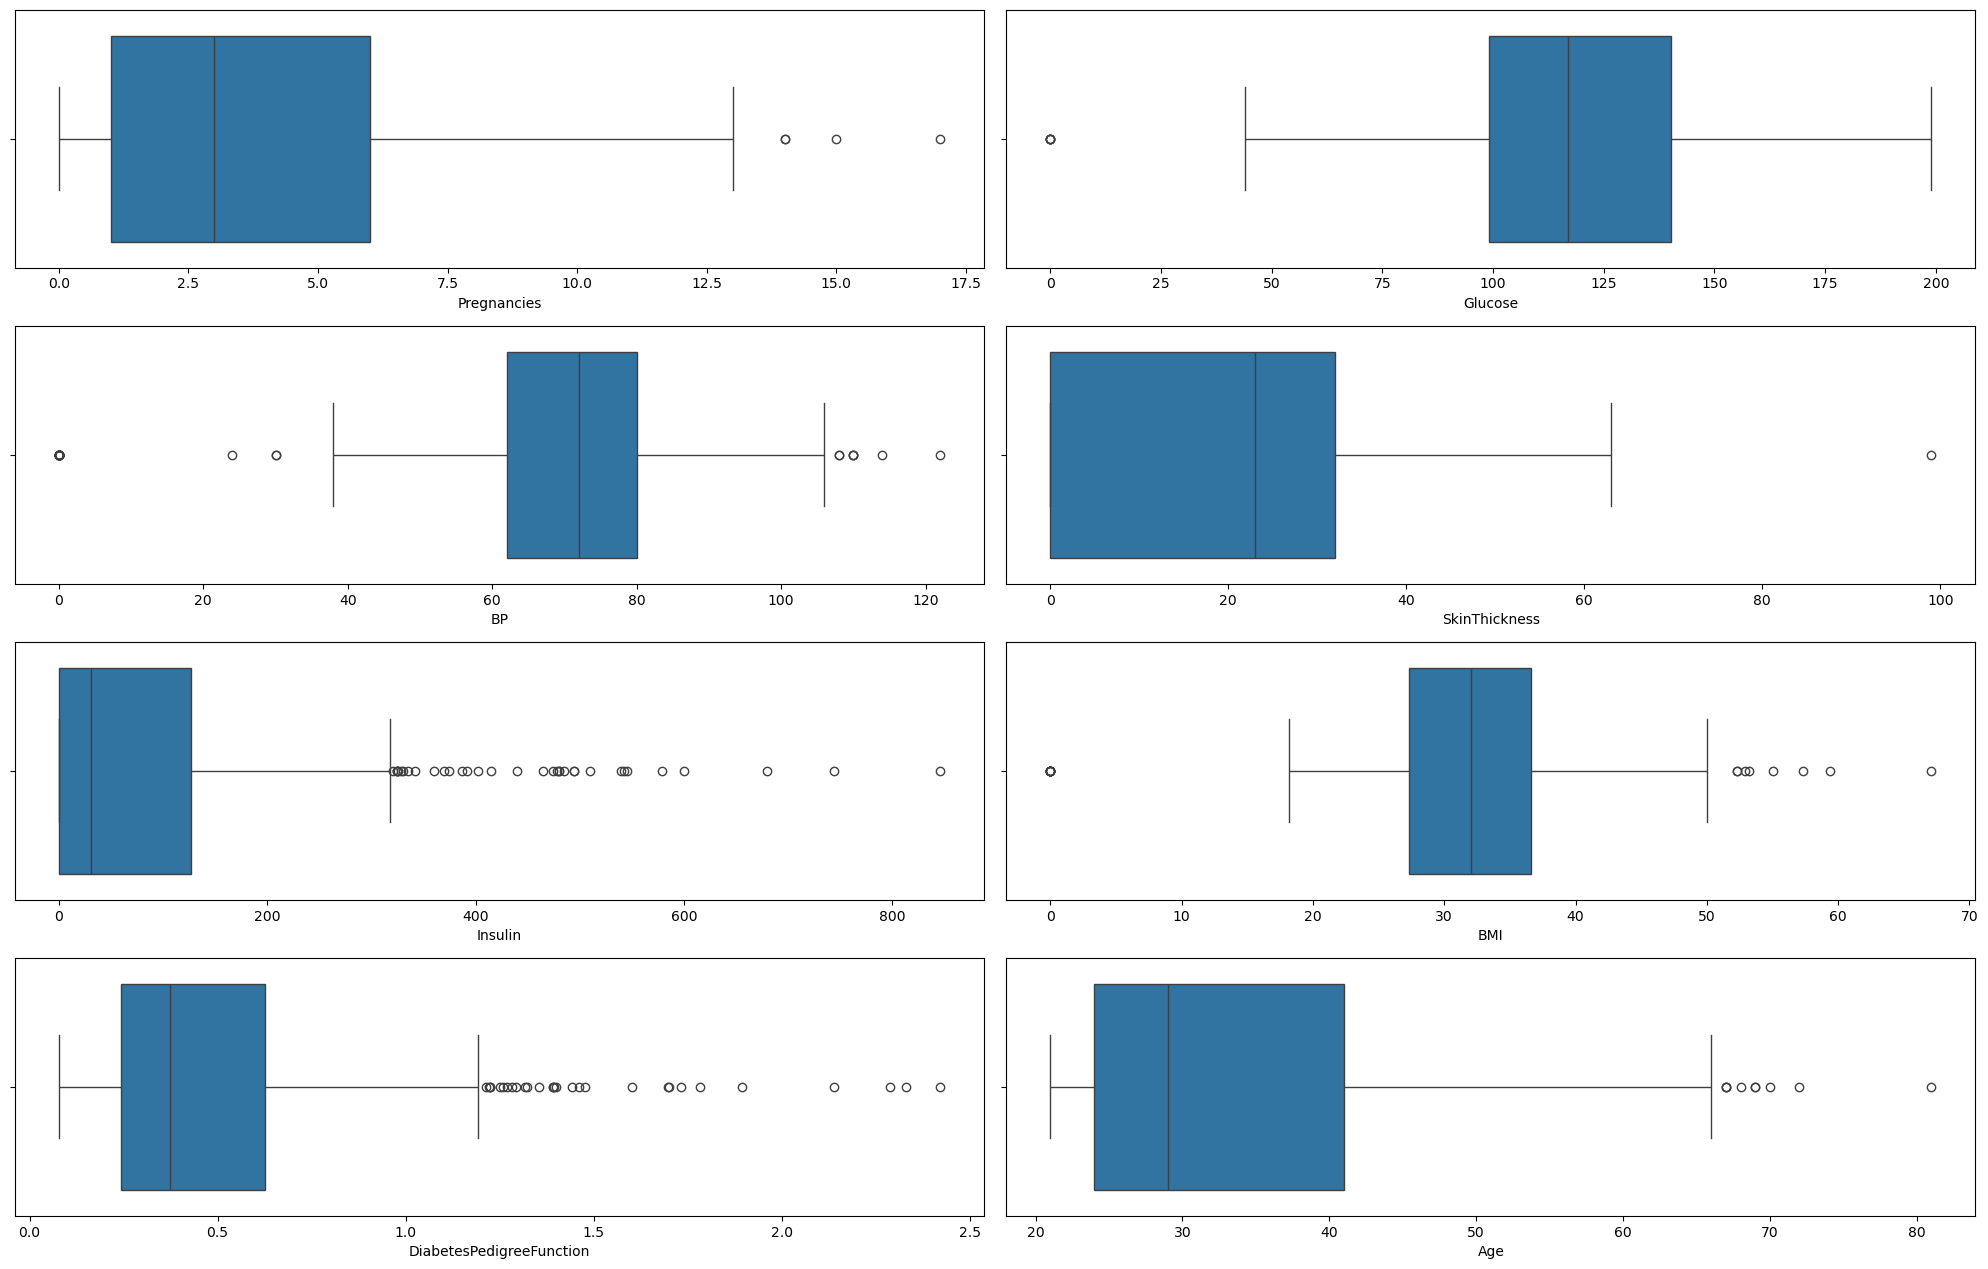

In [29]:
col = ['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age',]


plt.figure(figsize=(20,25))
for i, col in enumerate( col , 1 ): # why 1 here ? need to ask deep seek 
    plt.subplot(8, 2,i)
    sns.boxplot(x=uf[col] )
plt.tight_layout()
plt.show()


In [33]:
upperlimit = []
lowerlimit = []
col = ['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age',]
for i in col :
    upperlimit.append(uf[i].quantile(0.80))
    lowerlimit.append(uf[i].quantile(0.20))
lowerlimit

    

[np.float64(1.0),
 np.float64(95.0),
 np.float64(60.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(25.9),
 np.float64(0.2194),
 np.float64(23.0)]

In [34]:
upperlimit

[np.float64(7.0),
 np.float64(147.0),
 np.float64(82.0),
 np.float64(35.0),
 np.float64(150.0),
 np.float64(37.8),
 np.float64(0.687),
 np.float64(42.60000000000002)]

In [37]:
columns = ['Pregnancies','Glucose','BP','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

for idx, col_name in enumerate(columns):
    uf = uf[(uf[col_name] <= upperlimit[idx]) & (uf[col_name] >= lowerlimit[idx])]

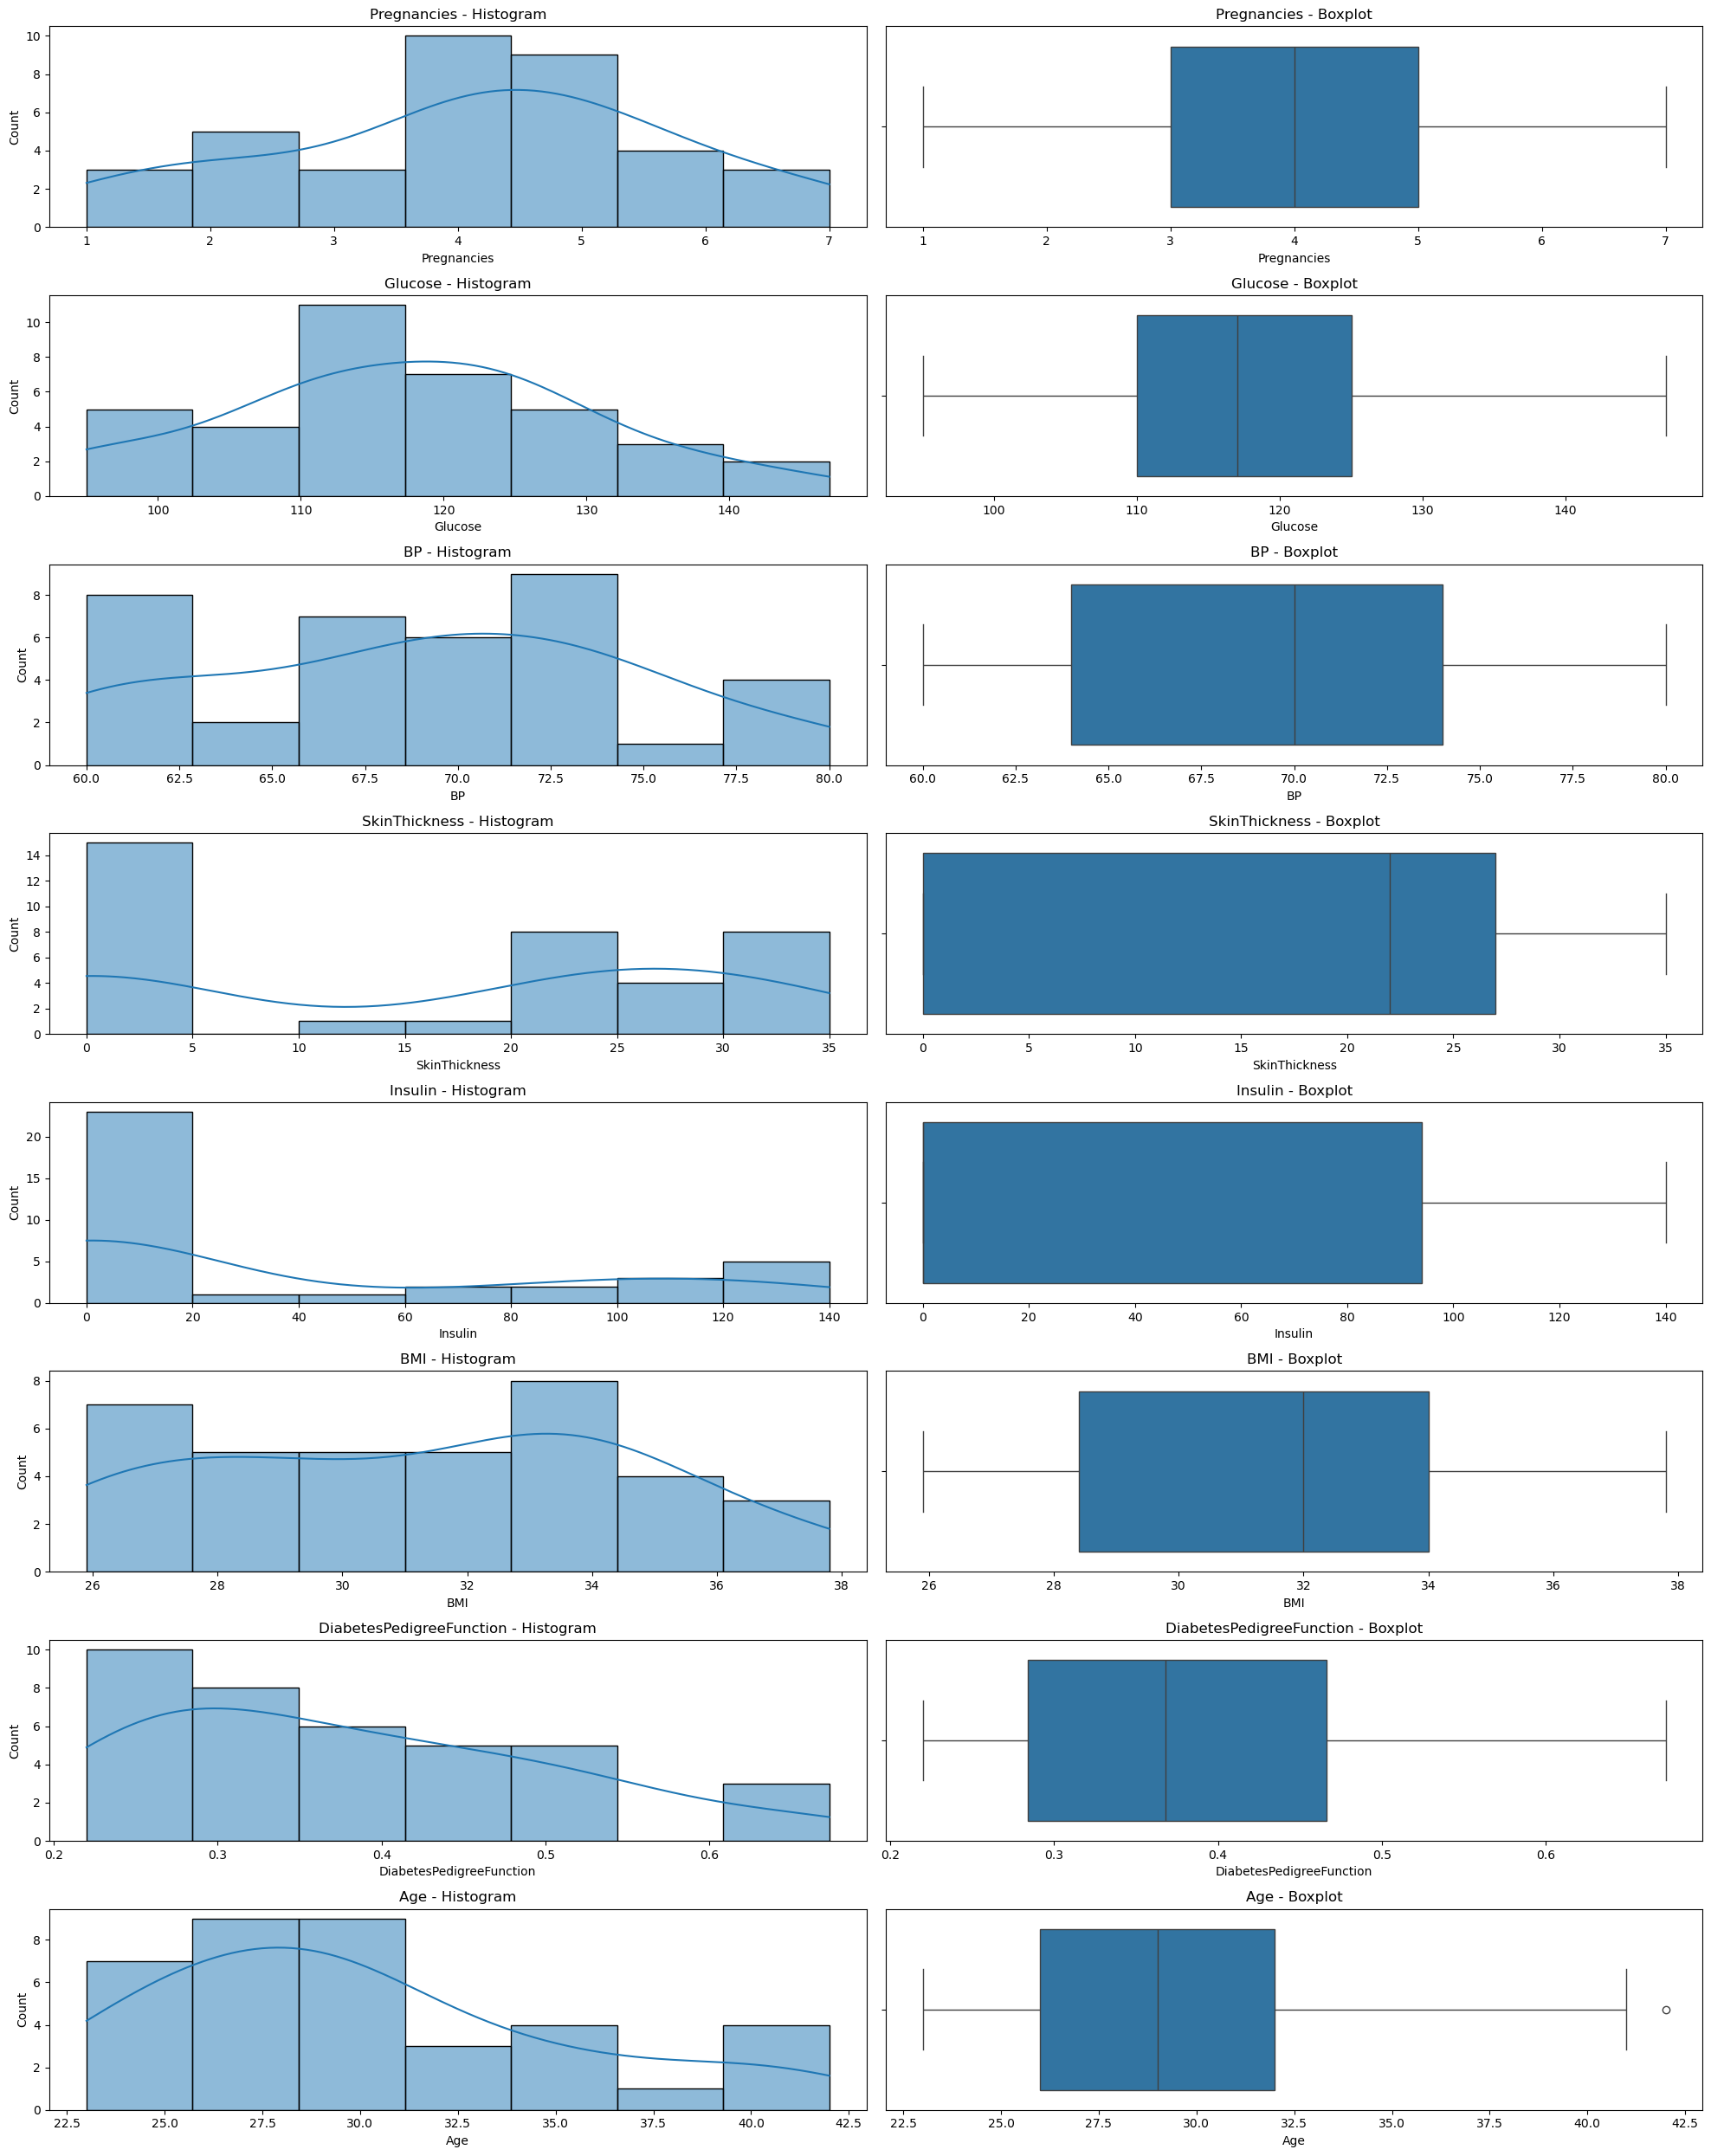

In [39]:
plt.figure(figsize=(20,25))
for i, col in enumerate(columns):
    # Histogram
    plt.subplot(8, 2, i*2 + 1)  # 8 rows, 2 columns, odd positions
    sns.histplot(uf[col], kde=True)
    plt.title(f'{col} - Histogram')
    
    # Boxplot
    plt.subplot(8, 2, i*2 + 2)  # 8 rows, 2 columns, even positions
    sns.boxplot(x=uf[col])
    plt.title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()